In [16]:
import pandas as pd
import numpy as np  
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [17]:
df = pd.read_csv(r'D:\datasets\email.csv')

In [18]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [20]:

df.columns = ['Category', 'Message']

In [21]:

df['Category'] = df['Category'].str.strip().str.lower()

df['Category'] = df['Category'].map({
    'ham': 0,
    'spam': 1
})


df = df.dropna(subset=['Category'])

In [22]:
X = df['Message']
y = df['Category']

In [25]:
vectorizer = TfidfVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

In [26]:
x_train, x_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)

In [27]:
model = MultinomialNB()
model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [28]:
y_pred = model.predict(x_test)

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9775784753363229
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       966
         1.0       1.00      0.83      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Confusion Matrix:
 [[966   0]
 [ 25 124]]


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

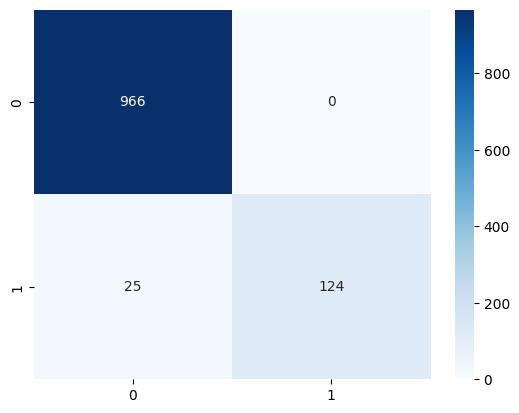

In [31]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')